In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# Baca file CSV
file_path = "/content/drive/MyDrive/smartphone.csv"
df = pd.read_csv(file_path)

# Tampilkan 5 baris pertama
df.head()


,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,...,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,snapdragon,8.0,3.2,...,6.70,120,1440 x 3216,3,1.0,android,50.0,16.0,0,NaN
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,81.0,True,False,False,snapdragon,8.0,2.2,...,6.59,120,1080 x 2412,3,1.0,android,64.0,16.0,1,1024.0
2,samsung,Samsung Galaxy A14 5G,16499,75.0,True,False,False,exynos,8.0,2.4,...,6.60,90,1080 x 2408,3,1.0,android,50.0,13.0,1,1024.0
3,motorola,Motorola Moto G62 5G,14999,81.0,True,False,False,snapdragon,8.0,2.2,...,6.55,120,1080 x 2400,3,1.0,android,50.0,16.0,1,1024.0
4,realme,Realme 10 Pro Plus,24999,82.0,True,False,False,dimensity,8.0,2.6,...,6.70,120,1080 x 2412,3,1.0,android,108.0,16.0,0,NaN


In [18]:
features = [
    'processor_speed',
    'num_cores',
    'ram_capacity',
    'internal_memory',
    'battery_capacity',
    'primary_camera_rear',
    'primary_camera_front',
    'rating',
    'price'
]

df[features].head()

,processor_speed,num_cores,ram_capacity,internal_memory,battery_capacity,primary_camera_rear,primary_camera_front,rating,price
0,3.2,8.0,12.0,256.0,5000.0,50.0,16.0,89.0,54999
1,2.2,8.0,6.0,128.0,5000.0,64.0,16.0,81.0,19989
2,2.4,8.0,4.0,64.0,5000.0,50.0,13.0,75.0,16499
3,2.2,8.0,6.0,128.0,5000.0,50.0,16.0,81.0,14999
4,2.6,8.0,6.0,128.0,5000.0,108.0,16.0,82.0,24999


Rows, cols: (980, 25)
brand_name                    object
model                         object
price                          int64
rating                       float64
has_5g                          bool
has_nfc                         bool
has_ir_blaster                  bool
processor_brand               object
num_cores                    float64
processor_speed              float64
battery_capacity             float64
fast_charging_available        int64
fast_charging                float64
ram_capacity                 float64
internal_memory              float64
screen_size                  float64
refresh_rate                   int64
resolution                    object
num_rear_cameras               int64
num_front_cameras            float64
os                            object
primary_camera_rear          float64
primary_camera_front         float64
extended_memory_available      int64
extended_upto                float64
dtype: object

Missing values per column:
brand_name 

,price
count,980.000000
mean,32520.504082
std,39531.812669
min,3499.000000
25%,12999.000000
50%,19994.500000
75%,35491.500000
max,650000.000000


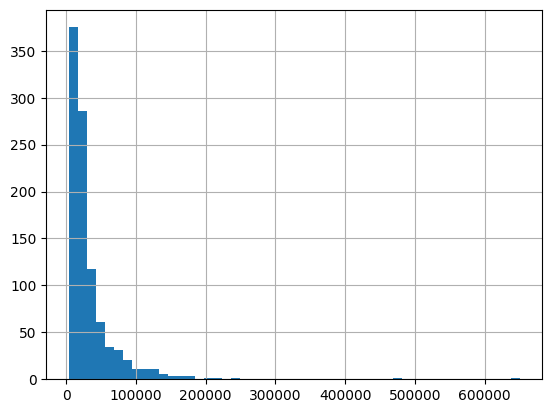

In [3]:
# Langkah 3: pemeriksaan kelengkapan data
# ==========================
print("Rows, cols:", df.shape)
print(df.dtypes)
print("\nMissing values per column:")
print(df.isna().sum())

# Lihat distribusi price
display(df['price'].describe())
_ = df['price'].hist(bins=50)

In [4]:
# ====== PERBAIKAN MISSING VALUES ======
# Cek tipe data
print(df.dtypes)

# Daftar kolom numerik dan kategorikal berdasarkan data Anda
num_cols = [
    'rating', 'processor_speed', 'battery_capacity',
    'num_cores', 'primary_camera_front', 'extended_upto'
]

cat_cols = [
    'processor_brand', 'os',
    'has_5g', 'has_nfc', 'has_ir_blaster',
    'fast_charging_available', 'fast_charging',
    'extended_memory_available'
]

# --- Isi nilai hilang numerik dengan median ---
for col in num_cols:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

# --- Isi nilai hilang kategorikal dengan modus (most frequent) ---
for col in cat_cols:
    if col in df.columns:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)

# --- Tangani kolom yang banyak kosong (contoh: extended_upto) ---
missing_ratio = df['extended_upto'].isna().mean() if 'extended_upto' in df.columns else 0
if missing_ratio > 0.4:
    print("Kolom 'extended_upto' banyak kosong (>{:.0%}) → akan dihapus.".format(missing_ratio))
    df = df.drop(columns=['extended_upto'], errors='ignore')

# --- Verifikasi hasil ---
print("\nJumlah missing value setelah perbaikan:")
print(df.isna().sum())


brand_name                    object
model                         object
price                          int64
rating                       float64
has_5g                          bool
has_nfc                         bool
has_ir_blaster                  bool
processor_brand               object
num_cores                    float64
processor_speed              float64
battery_capacity             float64
fast_charging_available        int64
fast_charging                float64
ram_capacity                 float64
internal_memory              float64
screen_size                  float64
refresh_rate                   int64
resolution                    object
num_rear_cameras               int64
num_front_cameras            float64
os                            object
primary_camera_rear          float64
primary_camera_front         float64
extended_memory_available      int64
extended_upto                float64
dtype: object

Jumlah missing value setelah perbaikan:
brand_name          

In [5]:
# Isi sisa nilai kosong di num_front_cameras dengan median
df['num_front_cameras'] = df['num_front_cameras'].fillna(df['num_front_cameras'].median())

# Pastikan sudah 0 semua
print("\nCek ulang missing values:")
print(df.isna().sum())



Cek ulang missing values:
brand_name                   0
model                        0
price                        0
rating                       0
has_5g                       0
has_nfc                      0
has_ir_blaster               0
processor_brand              0
num_cores                    0
processor_speed              0
battery_capacity             0
fast_charging_available      0
fast_charging                0
ram_capacity                 0
internal_memory              0
screen_size                  0
refresh_rate                 0
resolution                   0
num_rear_cameras             0
num_front_cameras            0
os                           0
primary_camera_rear          0
primary_camera_front         0
extended_memory_available    0
extended_upto                0
dtype: int64


In [6]:

from sklearn.preprocessing import MinMaxScaler

# Pilih fitur-fitur yang mencerminkan performa
perf_cols = [
    'processor_speed', 'num_cores', 'ram_capacity',
    'internal_memory', 'battery_capacity',
    'primary_camera_rear', 'primary_camera_front', 'rating'
]

# Normalisasi tiap kolom performa ke skala 0–1
mms = MinMaxScaler()
df['_perf_norm'] = mms.fit_transform(df[perf_cols]).mean(axis=1)

# Bagi performa jadi 3 kategori (low, medium, high)
df['_perf_cat'] = pd.qcut(df['_perf_norm'], q=3, labels=['low', 'medium', 'high'])

# Bagi harga jadi 3 kategori (budget, midrange, flagship)
df['_price_cat'] = pd.qcut(df['price'], q=3, labels=['budget', 'midrange', 'flagship'])

# Gabungkan menjadi label klasifikasi (segment)
def make_segment(row):
    if row['_price_cat']=='flagship' and row['_perf_cat']=='high':
        return 'Flagship'
    elif row['_price_cat']=='budget' and row['_perf_cat']=='low':
        return 'Budget'
    else:
        return 'Midrange'

df['segment'] = df.apply(make_segment, axis=1)

# Cek distribusi kelas
print("Distribusi label (segment):")
print(df['segment'].value_counts())


Distribusi label (segment):
segment
Midrange    485
Budget      251
Flagship    244
Name: count, dtype: int64


In [7]:
# Tentukan fitur untuk model (fitur performa + harga)
features = [
    'processor_speed', 'num_cores', 'ram_capacity',
    'internal_memory', 'battery_capacity',
    'primary_camera_rear', 'primary_camera_front', 'rating', 'price'
]

X = df[features].copy()
y = df['segment'].copy()

# Encode label ke bentuk numerik (0, 1, 2)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Kelas:", list(le.classes_))


Kelas: ['Budget', 'Flagship', 'Midrange']


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

print("Ukuran data train:", X_train.shape)
print("Ukuran data test:", X_test.shape)


Ukuran data train: (735, 9)
Ukuran data test: (245, 9)


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': [3,5,7,9,11],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1,2]  # p=1 Manhattan, p=2 Euclidean
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'knn__n_neighbors': 7, 'knn__p': 2, 'knn__weights': 'distance'}
Best CV score: 0.889795918367347


Akurasi Uji: 0.9224489795918367

Laporan Klasifikasi:
              precision    recall  f1-score   support

      Budget       0.91      0.94      0.92        63
    Flagship       0.93      0.92      0.93        61
    Midrange       0.93      0.92      0.92       121

    accuracy                           0.92       245
   macro avg       0.92      0.92      0.92       245
weighted avg       0.92      0.92      0.92       245



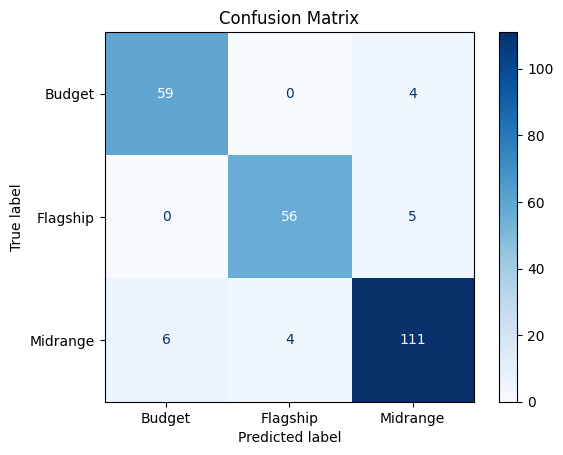

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Akurasi Uji:", accuracy_score(y_test, y_pred))
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


In [11]:
import joblib, os

model_path = '/content/drive/MyDrive/models/knn_smartphone_segment.joblib'
os.makedirs(os.path.dirname(model_path), exist_ok=True)

joblib.dump({'model': best_model, 'label_encoder': le, 'scaler': mms}, model_path)
print("Model tersimpan di:", model_path)


Model tersimpan di: /content/drive/MyDrive/models/knn_smartphone_segment.joblib


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Fit scaler pada data training
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Latih KNN
best_model = KNeighborsClassifier(n_neighbors=5)
best_model.fit(X_train_scaled, y_train)


KNeighborsClassifier()

In [17]:
import pandas as pd

X_scaled = scaler.fit_transform(X)

# Ubah ke DataFrame supaya bisa ditampilkan
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.head()

,processor_speed,num_cores,ram_capacity,internal_memory,battery_capacity,primary_camera_rear,primary_camera_front,rating,price
0,1.712195,0.271606,1.983172,1.073622,0.179573,-0.009680,-0.054053,1.503094,0.568908
1,-0.487906,0.271606,-0.204232,-0.121748,0.179573,0.414767,-0.054053,0.364628,-0.317160
2,-0.047886,0.271606,-0.933367,-0.719433,0.179573,-0.009680,-0.330715,-0.489221,-0.405488
3,-0.487906,0.271606,-0.204232,-0.121748,0.179573,-0.009680,-0.054053,0.364628,-0.443452
4,0.392134,0.271606,-0.204232,-0.121748,0.179573,1.748742,-0.054053,0.506937,-0.190362


In [13]:
# ==========================
# 1️⃣ IMPORT PICKLE
# ==========================

import pickle

# ==========================
# 2️⃣ SIMPAN MODEL, SCALER, LABEL ENCODER
# ==========================
# Simpan ke file .pkl
with open('/content/knn_model.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model,
        'scaler': scaler,
        'label_encoder': le
    }, f)

print("Model, scaler, dan label encoder berhasil disimpan sebagai knn_model.pkl")


Model, scaler, dan label encoder berhasil disimpan sebagai knn_model.pkl


In [14]:
# ==========================
# 3️⃣ LOAD MODEL DARI FILE
# ==========================
with open('/content/knn_model.pkl', 'rb') as f:
    data = pickle.load(f)

model_loaded = data['model']
scaler_loaded = data['scaler']
le_loaded = data['label_encoder']


In [15]:
# ==========================
# 1️⃣ Import library
# ==========================
import ipywidgets as widgets
from IPython.display import display

# ==========================
# 2️⃣ Buat form input
# ==========================
processor_speed_widget = widgets.FloatText(description='Processor (GHz):', value=2.8)
num_cores_widget = widgets.IntText(description='Core:', value=8)
ram_widget = widgets.FloatText(description='RAM (GB):', value=12)
internal_memory_widget = widgets.FloatText(description='Internal (GB):', value=256)
battery_widget = widgets.FloatText(description='Battery (mAh):', value=5000)
rear_cam_widget = widgets.FloatText(description='Rear Cam (MP):', value=50)
front_cam_widget = widgets.FloatText(description='Front Cam (MP):', value=32)
rating_widget = widgets.FloatText(description='Rating (0-100):', value=90)
price_widget = widgets.FloatText(description='Price:', value=7000)

predict_button = widgets.Button(description="Prediksi Segment")

# ==========================
# 3️⃣ Fungsi prediksi
# ==========================
def prediksi_segment(b):
    new_phone = [[
        processor_speed_widget.value,
        num_cores_widget.value,
        ram_widget.value,
        internal_memory_widget.value,
        battery_widget.value,
        rear_cam_widget.value,
        front_cam_widget.value,
        rating_widget.value,
        price_widget.value
    ]]
    # Scaling
    new_phone_scaled = scaler_loaded.transform(new_phone)
    # Prediksi
    pred = model_loaded.predict(new_phone_scaled)
    segment_pred = le_loaded.inverse_transform(pred)
    print(f"Segmentasi smartphone: {segment_pred[0]}")

predict_button.on_click(prediksi_segment)

# ==========================
# 4️⃣ Tampilkan form
# ==========================
display(processor_speed_widget, num_cores_widget, ram_widget,
        internal_memory_widget, battery_widget, rear_cam_widget,
        front_cam_widget, rating_widget, price_widget, predict_button)


FloatText(value=2.8, description='Processor (GHz):')

IntText(value=8, description='Core:')

FloatText(value=12.0, description='RAM (GB):')

FloatText(value=256.0, description='Internal (GB):')

FloatText(value=5000.0, description='Battery (mAh):')

FloatText(value=50.0, description='Rear Cam (MP):')

FloatText(value=32.0, description='Front Cam (MP):')

FloatText(value=90.0, description='Rating (0-100):')

FloatText(value=7000.0, description='Price:')

Button(description='Prediksi Segment', style=ButtonStyle())

In [16]:
# ==================================================
# PIPELINE PENGUJIAN MODEL KNN BERDASARKAN NAMA HP
# ==================================================

# 1️⃣ IMPORT LIBRARY
import pandas as pd
import pickle
import ipywidgets as widgets
from IPython.display import display, clear_output


# 2️⃣ LOAD DATASET (UNTUK LOOKUP SPESIFIKASI)
df = pd.read_csv('/content/drive/MyDrive/smartphone.csv')


# 3️⃣ LOAD MODEL
with open('/content/knn_model.pkl', 'rb') as f:
    data = pickle.load(f)

model_loaded = data['model']
scaler_loaded = data['scaler']
le_loaded = data['label_encoder']


# 4️⃣ DEFINISI FITUR (HARUS SAMA DENGAN TRAINING)
FEATURE_COLS = [
    'processor_speed',
    'num_cores',
    'ram_capacity',
    'internal_memory',
    'battery_capacity',
    'primary_camera_rear',
    'primary_camera_front',
    'rating',
    'price'
]


# 5️⃣ FORM INPUT (MODEL SMARTPHONE)
model_widget = widgets.Dropdown(
    options=sorted(df['model'].unique()),
    description='Model HP:'
)

predict_button = widgets.Button(description='Prediksi Segment')
output = widgets.Output()


# 6️⃣ FUNGSI PENGUJIAN (PIPELINE INTI)
def pipeline_uji_model(b):
    with output:
        clear_output()

        # Ambil model HP yang dipilih
        model_hp = model_widget.value

        # Ambil data sesuai model HP
        row = df[df['model'] == model_hp].iloc[0]

        # Ambil fitur numerik
        fitur = row[FEATURE_COLS].values.reshape(1, -1)

        # Scaling
        fitur_scaled = scaler_loaded.transform(fitur)

        # Prediksi KNN
        pred = model_loaded.predict(fitur_scaled)
        segment = le_loaded.inverse_transform(pred)[0]

        # OUTPUT
        print("📱 HASIL PENGUJIAN MODEL SMARTPHONE")
        print("===================================")
        print(f"Model HP        : {model_hp}")
        print(f"Brand           : {row['brand_name']}")
        print("")
        print("📊 Spesifikasi Perangkat")
        print("-----------------------------------")
        print(f"Processor Speed : {row['processor_speed']} GHz")
        print(f"Jumlah Core     : {row['num_cores']}")
        print(f"RAM             : {row['ram_capacity']} GB")
        print(f"Internal Memory : {row['internal_memory']} GB")
        print(f"Baterai         : {row['battery_capacity']} mAh")
        print(f"Kamera Belakang : {row['primary_camera_rear']} MP")
        print(f"Kamera Depan    : {row['primary_camera_front']} MP")
        print(f"Rating          : {row['rating']}")
        print(f"Harga           : Rp {row['price']}")
        print("")
        print("🔮 Hasil Prediksi Model")
        print("-----------------------------------")
        print(f"Prediksi Segment: {segment}")


# 7️⃣ EVENT & TAMPILAN
predict_button.on_click(pipeline_uji_model)
display(model_widget, predict_button, output)


Dropdown(description='Model HP:', options=('Apple iPhone 11', 'Apple iPhone 11 (128GB)', 'Apple iPhone 11 Pro …

Button(description='Prediksi Segment', style=ButtonStyle())

Output()